# Signal Evidence: Is the Chosen Signal Trustworthy?

**Docker image**: `ml4t`

This is NOT a full recap of Ch11-15's model family narrative. It shows
**only** the signal evidence that matters for downstream trading decisions:
validation IC, holdout IC, stability, reproducibility flags, and whether
the chosen signal is trustworthy enough to trade on.

**Scope rule**: Ch11-15 insight notebooks teach what each model family
reveals. This notebook asks: does the best signal per case study
survive scrutiny?

**Learning Objectives**:
- Assess which case studies have trustworthy signal evidence
- Compare validation IC with holdout IC (signal persistence)
- Identify reproducibility and stability concerns

**Book Reference**: Chapter 20, Section 20.2 (Signal Evidence)

**Prerequisites**: Run [`01_aggregate_synthesis`](01_aggregate_synthesis.ipynb) first.

In [1]:
"""Ch20 Signal Evidence — only the signal evidence that matters for trading decisions."""

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

warnings.filterwarnings("ignore")

from utils.paths import get_chapter_dir

In [2]:
MAX_SYMBOLS = 0

In [3]:
OUTPUT_DIR = get_chapter_dir(20) / "output"

# Display names
DISPLAY_NAMES = {
    "etfs": "ETFs",
    "crypto_perps_funding": "Crypto",
    "nasdaq100_microstructure": "NASDAQ-100",
    "sp500_equity_option_analytics": "S&P 500 Eq+Opt",
    "us_firm_characteristics": "US Firms",
    "fx_pairs": "FX Pairs",
    "cme_futures": "CME Futures",
    "sp500_options": "S&P 500 Options",
    "us_equities_panel": "US Equities",
}

FAMILY_NAMES = {
    "linear": "Linear",
    "gbm": "GBM",
    "deep_learning": "Deep Learning",
    "tabular_dl": "Tabular DL",
    "latent_factors": "Latent Factors",
}

## Load Data

In [4]:
ic_df = pl.read_parquet(OUTPUT_DIR / "ic_comparison.parquet")
variant_df = pl.read_parquet(OUTPUT_DIR / "variant_analysis.parquet")
synthesis = json.load((OUTPUT_DIR / "all_synthesis.json").open())

print(f"IC comparison: {len(ic_df)} entries across {ic_df['case_study'].n_unique()} case studies")
print(
    f"Variant analysis: {len(variant_df)} variants across {variant_df['case_study'].n_unique()} case studies"
)

IC comparison: 39 entries across 9 case studies
Variant analysis: 423 variants across 9 case studies


## IC Landscape Heatmap

Which model families produce the strongest signals for which asset classes?

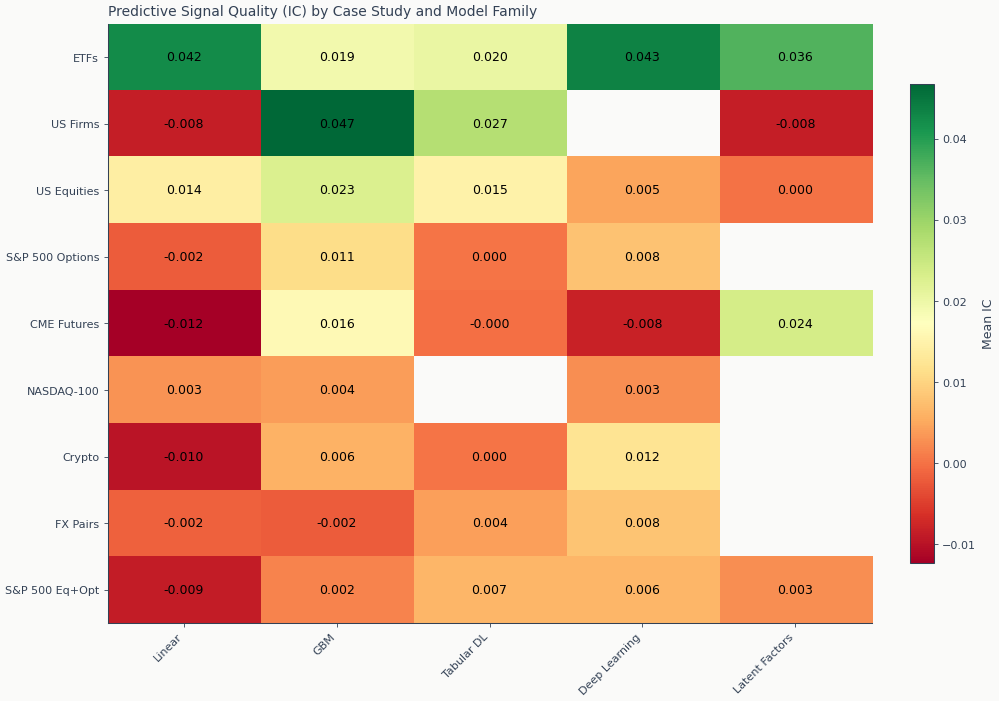

In [5]:
# Build IC matrix: case study × model family
ic_matrix = ic_df.pivot(on="family", index="case_study", values="ic_mean")

# Order case studies by average IC
case_order = (
    ic_df.group_by("case_study")
    .agg(avg_ic=pl.col("ic_mean").mean())
    .sort("avg_ic", descending=True)["case_study"]
    .to_list()
)

family_order = ["linear", "gbm", "tabular_dl", "deep_learning", "latent_factors"]
family_labels = [FAMILY_NAMES.get(f, f) for f in family_order]

# Build matrix for heatmap
matrix_data = []
for cs in case_order:
    row = []
    for fam in family_order:
        val = ic_matrix.filter(pl.col("case_study") == cs).select(fam)
        if len(val) > 0 and val[0, 0] is not None:
            row.append(float(val[0, 0]))
        else:
            row.append(np.nan)
    matrix_data.append(row)

matrix_arr = np.array(matrix_data)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(matrix_arr, cmap="RdYlGn", aspect="auto")

ax.set_xticks(range(len(family_labels)))
ax.set_xticklabels(family_labels, rotation=45, ha="right")
ax.set_yticks(range(len(case_order)))
ax.set_yticklabels(case_order)

# Annotate cells
for i in range(len(case_order)):
    for j in range(len(family_order)):
        val = matrix_arr[i, j]
        if not np.isnan(val):
            color = "white" if abs(val) > 0.15 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9, color=color)

plt.colorbar(im, ax=ax, label="Mean IC", shrink=0.8)
ax.set_title("Predictive Signal Quality (IC) by Case Study and Model Family")
fig.subplots_adjust(left=0.2, right=0.92, top=0.9, bottom=0.18)
fig.show()

## Signal Sharpe Heatmap

The IC heatmap above measures *prediction quality*. This companion heatmap
measures *signal quality* — the median Sharpe when predictions from each
family are converted into positions. The two rankings often disagree:
a family can lead on average IC but not on median signal Sharpe, or
vice versa. This is the first concrete view of the IC-to-Sharpe disconnect
that Section 20.3 explores in detail.

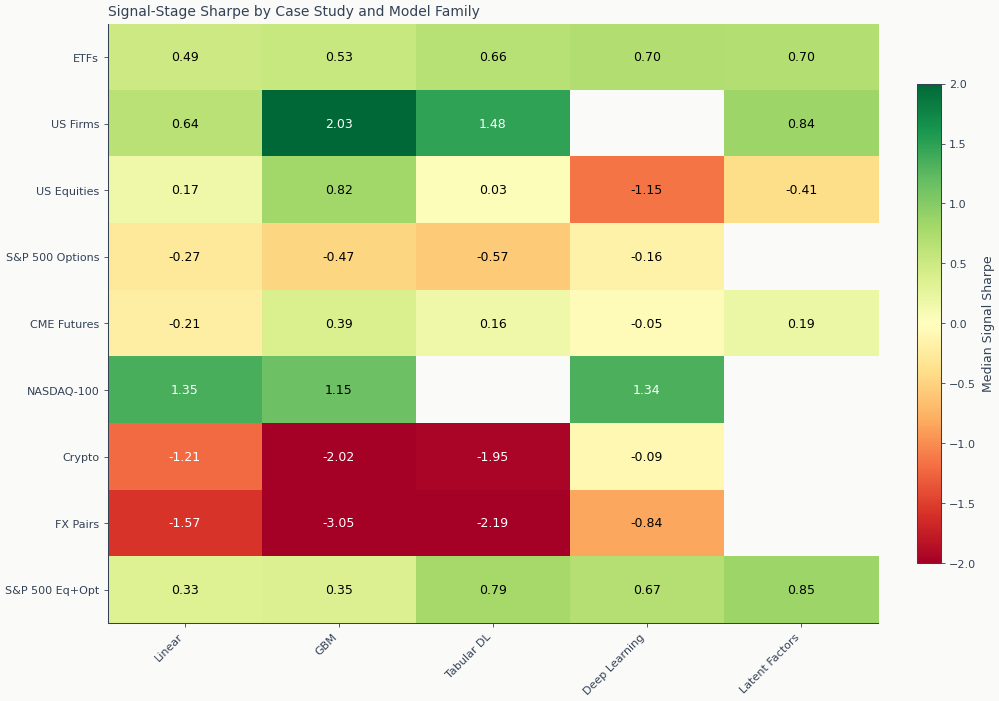

In [6]:
sharpe_matrix = (
    variant_df.filter(pl.col("sharpe").is_not_null())
    .group_by("case_study", "family")
    .agg(median_sharpe=pl.col("sharpe").median())
    .pivot(on="family", index="case_study", values="median_sharpe")
)

sharpe_data = []
sharpe_rows = []
for cs in case_order:
    sub = sharpe_matrix.filter(pl.col("case_study") == cs)
    if sub.is_empty():
        continue
    row = []
    for fam in family_order:
        if fam in sub.columns:
            v = sub[fam].item()
            row.append(float(v) if v is not None else np.nan)
        else:
            row.append(np.nan)
    sharpe_data.append(row)
    sharpe_rows.append(cs)

sharpe_arr = np.array(sharpe_data)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(sharpe_arr, cmap="RdYlGn", aspect="auto", vmin=-2, vmax=2)

ax.set_xticks(range(len(family_labels)))
ax.set_xticklabels(family_labels, rotation=45, ha="right")
ax.set_yticks(range(len(sharpe_rows)))
ax.set_yticklabels(sharpe_rows)

for i in range(len(sharpe_rows)):
    for j in range(len(family_order)):
        val = sharpe_arr[i, j]
        if not np.isnan(val):
            color = "white" if abs(val) > 1.2 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color)

plt.colorbar(im, ax=ax, label="Median Signal Sharpe", shrink=0.8)
ax.set_title("Signal-Stage Sharpe by Case Study and Model Family")
fig.subplots_adjust(left=0.2, right=0.92, top=0.9, bottom=0.18)
fig.show()

Reading the IC and Sharpe heatmaps together separates ranking quality
(signal Sharpe) from average prediction quality (IC). GBM typically shows
the widest within-family Sharpe spread: its highest-Sharpe configuration
may be 2+ Sharpe points above its median. Latent factors and deep learning
can have the highest signal Sharpe on ETFs and the S&P 500 studies in
cases where a different family has the highest average IC — top-k ranking
accuracy and average IC are not the same measurement.

## Model Family Comparison

Which model family is most consistently effective across asset classes?

In [7]:
family_stats = (
    ic_df.group_by("family")
    .agg(
        n_studies=pl.col("case_study").n_unique(),
        mean_ic=pl.col("ic_mean").mean(),
        median_ic=pl.col("ic_mean").median(),
        std_ic=pl.col("ic_mean").std(),
        max_ic=pl.col("ic_mean").max(),
        min_ic=pl.col("ic_mean").min(),
        n_positive=(pl.col("ic_mean") > 0).sum(),
    )
    .sort("mean_ic", descending=True)
)

### Model Family Summary

In [8]:
family_stats

family,n_studies,mean_ic,median_ic,std_ic,max_ic,min_ic,n_positive
str,u32,f64,f64,f64,f64,f64,u32
"""gbm""",9,0.013982,0.011221,0.01482,0.046776,-0.001997,8
"""latent_factors""",5,0.010856,0.0025,0.018544,0.036478,-0.008372,4
"""deep_learning""",8,0.009659,0.007251,0.014885,0.043374,-0.008118,7
"""tabular_dl""",8,0.009145,0.005336,0.010397,0.027168,-0.000269,7
"""linear""",9,0.001878,-0.001997,0.017194,0.042262,-0.012294,3


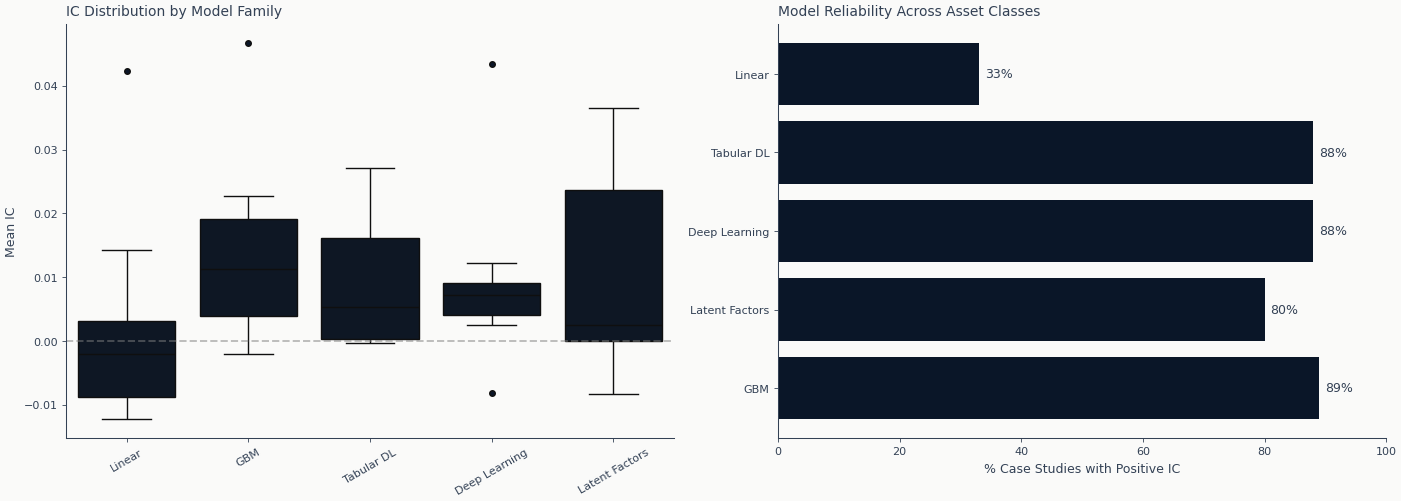

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
ic_pandas = ic_df.to_pandas()
ic_pandas["family_label"] = ic_pandas["family"].map(FAMILY_NAMES)
sns.boxplot(
    data=ic_pandas,
    x="family_label",
    y="ic_mean",
    ax=axes[0],
    order=[FAMILY_NAMES[f] for f in family_order if f in ic_pandas["family"].values],
)
axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean IC")
axes[0].set_title("IC Distribution by Model Family")
axes[0].tick_params(axis="x", rotation=30)

# Bar chart: count of positive ICs
pos_counts = family_stats.with_columns(
    pct_positive=(pl.col("n_positive") / pl.col("n_studies") * 100).round(0),
)
fam_labels = [FAMILY_NAMES.get(f, f) for f in pos_counts["family"].to_list()]
axes[1].barh(fam_labels, pos_counts["pct_positive"].to_list())
axes[1].set_xlabel("% Case Studies with Positive IC")
axes[1].set_title("Model Reliability Across Asset Classes")
axes[1].set_xlim(0, 100)
for i, v in enumerate(pos_counts["pct_positive"].to_list()):
    axes[1].text(v + 1, i, f"{v:.0f}%", va="center")

fig.show()

## IC by Asset Class Characteristics

Does universe size, frequency, or cost regime predict IC?

In [10]:
meta_rows = []
for cs, data in synthesis.items():
    meta = data["meta"]
    models = data["pipeline_summary"]["models"]
    best_ic = max((m.get("ic_mean", 0) or 0) for m in models.values()) if models else 0.0
    meta_rows.append(
        {
            "case_study": DISPLAY_NAMES.get(cs, cs),
            "universe_size": meta["universe_size"],
            "frequency": meta["frequency"],
            "cost_bps": meta["cost_bps"],
            "best_ic": best_ic,
            "n_families": len(data["pipeline_summary"]["models"]),
        }
    )

meta_df = pl.DataFrame(meta_rows)

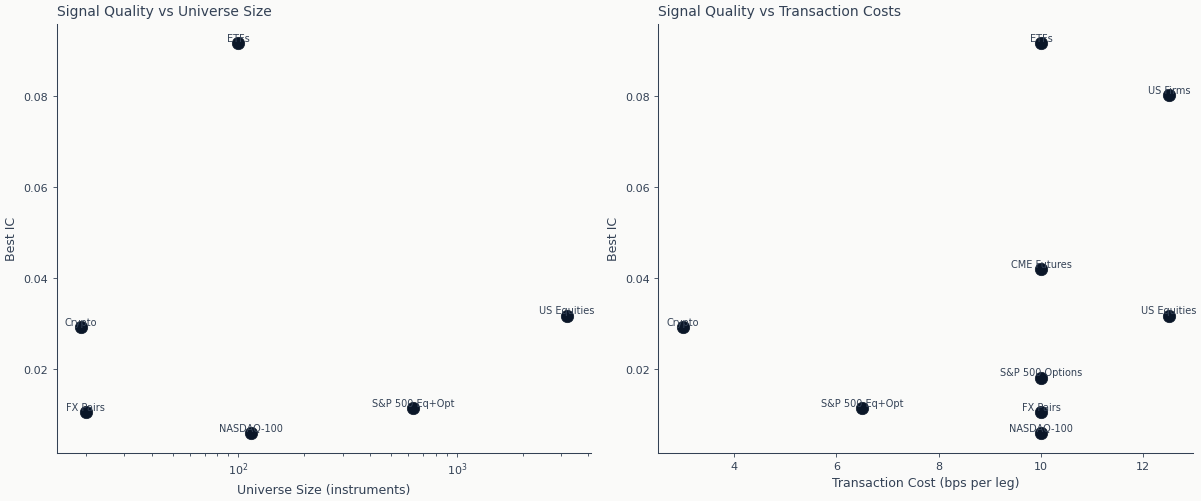

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# IC vs universe size
meta_pd = meta_df.to_pandas()
axes[0].scatter(meta_pd["universe_size"], meta_pd["best_ic"], s=80)
for _, row in meta_pd.iterrows():
    axes[0].annotate(
        row["case_study"],
        (row["universe_size"], row["best_ic"]),
        fontsize=7,
        ha="center",
        va="bottom",
    )
axes[0].set_xlabel("Universe Size (instruments)")
axes[0].set_ylabel("Best IC")
axes[0].set_title("Signal Quality vs Universe Size")
axes[0].set_xscale("log")

# IC vs cost
axes[1].scatter(meta_pd["cost_bps"], meta_pd["best_ic"], s=80)
for _, row in meta_pd.iterrows():
    axes[1].annotate(
        row["case_study"], (row["cost_bps"], row["best_ic"]), fontsize=7, ha="center", va="bottom"
    )
axes[1].set_xlabel("Transaction Cost (bps per leg)")
axes[1].set_ylabel("Best IC")
axes[1].set_title("Signal Quality vs Transaction Costs")

fig.show()

## Key Takeaways

1. **IC spans roughly two orders of magnitude** across asset classes — from
   near-zero (NASDAQ-100, FX Pairs, crypto) to ~0.04–0.05 (ETFs and US Firms),
   plausibly because momentum and cross-sectional signals on those datasets
   are more persistent
2. **Tree-based and factor models carry the strongest signal** — GBM posts the
   highest mean IC overall (0.014, positive on eight of nine case studies),
   while deep-learning and latent-factor families lead the remaining datasets;
   linear models are competitive only on ETFs and US Equities and trail badly
   on CME Futures (lowest, negative mean IC)
3. **No single model family has the highest IC in every case study** — GBM
   leads on US Firms, US Equities, and the options datasets; deep-learning
   leads on ETFs, crypto, and FX Pairs; latent factors lead on CME Futures;
   the highest-IC family is dataset-specific
4. **Universe size is not predictive** of IC — what matters is feature quality and
   the predictability horizon

**Next**: [`04_signal_to_strategy`](04_signal_to_strategy.ipynb) explores the gap between IC and Sharpe.